In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
wcss = []
sil_scores = []

K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # sum of squared distances
    labels = kmeans.labels_
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [6]:
OMP_NUM_THREADS=1

Text(0.5, 1.0, 'Elbow Method')

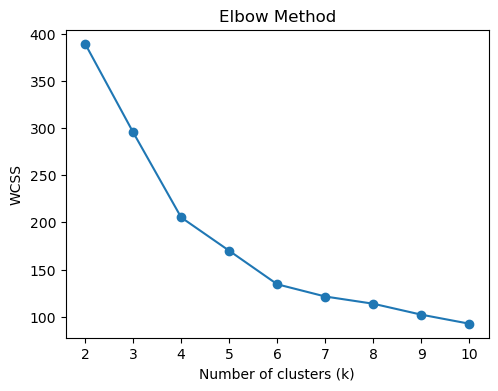

In [7]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K, wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

Text(0.5, 1.0, 'Silhouette Analysis')

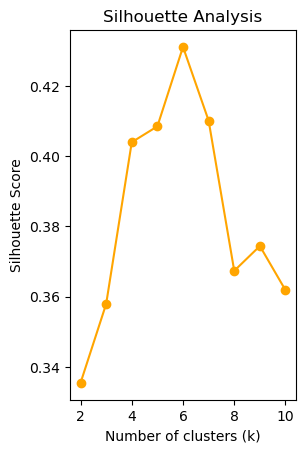

In [8]:
plt.subplot(1,2,2)
plt.plot(K, sil_scores, marker='o', color='orange')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

In [9]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [10]:
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['Cluster_KMeans'] = kmeans_labels

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [11]:
Z = linkage(X_scaled, method='ward')

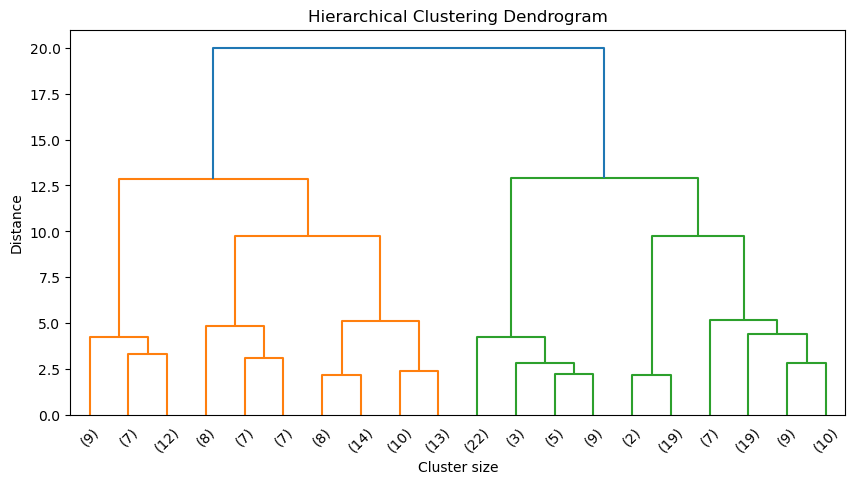

In [12]:
plt.figure(figsize=(10,5))
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=45., leaf_font_size=10.)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.show()

In [13]:
hclust = AgglomerativeClustering(n_clusters=k_opt, affinity='euclidean', linkage='ward')
h_labels = hclust.fit_predict(X_scaled)
df['Cluster_Hier'] = h_labels

TypeError: AgglomerativeClustering.__init__() got an unexpected keyword argument 'affinity'

In [14]:
hclust = AgglomerativeClustering(n_clusters=k_opt, metric='euclidean', linkage='ward')
h_labels = hclust.fit_predict(X_scaled)
df['Cluster_Hier'] = h_labels

In [15]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)
df['Cluster_DBSCAN'] = db_labels

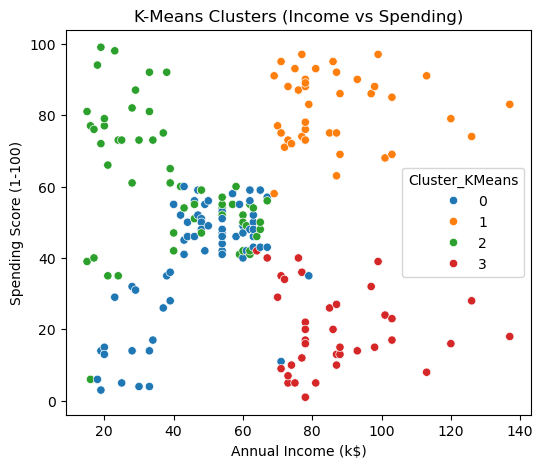

In [16]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Cluster_KMeans', palette='tab10'
)
plt.title("K-Means Clusters (Income vs Spending)")
plt.show()

In [17]:
cluster_profile = df.groupby('Cluster_KMeans')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean()
print(cluster_profile)

                      Age  Annual Income (k$)  Spending Score (1-100)
Cluster_KMeans                                                       
0               53.984615           47.707692               39.969231
1               32.875000           86.100000               81.525000
2               25.438596           40.000000               60.298246
3               39.368421           86.500000               19.578947
